<a href="https://colab.research.google.com/github/Raka7317/DATA-STRUCTURE-/blob/main/text_speech2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracting...
Done!

Total audio files found: 1440

Emotion distribution:
emotion
happy        192
sad          192
surprised    192
fearful      192
angry        192
calm         192
disgust      192
neutral       96
Name: count, dtype: int64


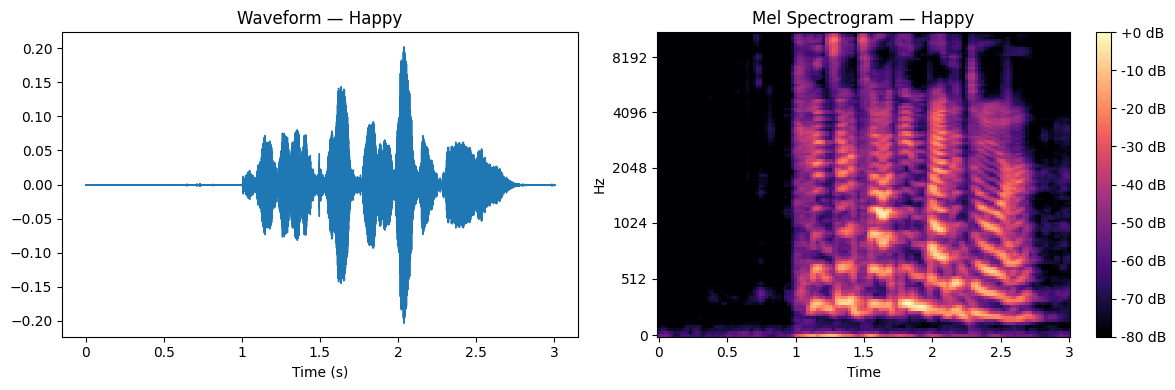


Step 1 complete! Run Step 2 next.
Dataset saved to df variable with 1440 samples.


In [5]:
# ============================================================
# STEP 1: Install Libraries and Load RAVDESS Dataset
# Copy-paste this entire block into a Colab cell and run it
# ============================================================

# Install required libraries
!pip install librosa soundfile kaggle -q

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import urllib.request
import zipfile

# ----------------------------
# 1. Download RAVDESS dataset
# ----------------------------
print("Downloading RAVDESS dataset...")

# Download directly from Zenodo (no login needed)
url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
zip_path = "ravdess.zip"

if not os.path.exists("RAVDESS"):
    urllib.request.urlretrieve(url, zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("RAVDESS")
    os.remove(zip_path)
    print("Done!")
else:
    print("Dataset already exists, skipping download.")

# ----------------------------
# 2. Understand the file naming
# ----------------------------
# RAVDESS filename format:
# 03-01-06-01-02-01-12.wav
# Position 3 (index 2) = Emotion:
# 01=neutral, 02=calm, 03=happy, 04=sad,
# 05=angry, 06=fearful, 07=disgust, 08=surprised

emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# ----------------------------
# 3. Load all audio file paths
# ----------------------------
audio_files = list(Path("RAVDESS").rglob("*.wav"))
print(f"\nTotal audio files found: {len(audio_files)}")

data = []
for f in audio_files:
    parts = f.stem.split("-")
    emotion_code = parts[2]
    emotion = emotion_map.get(emotion_code, "unknown")
    data.append({"path": str(f), "emotion": emotion})

df = pd.DataFrame(data)
print("\nEmotion distribution:")
print(df["emotion"].value_counts())

# ----------------------------
# 4. Visualize a sample waveform + spectrogram
# ----------------------------
sample_file = df[df["emotion"] == "happy"]["path"].iloc[0]
y, sr = librosa.load(sample_file, duration=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Waveform
axes[0].set_title("Waveform — Happy")
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_xlabel("Time (s)")

# Mel Spectrogram
mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel, ref=np.max)
img = librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                                y_axis='mel', ax=axes[1])
axes[1].set_title("Mel Spectrogram — Happy")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.savefig("sample_spectrogram.png", dpi=150)
plt.show()

print("\nStep 1 complete! Run Step 2 next.")
print(f"Dataset saved to df variable with {len(df)} samples.")

Extracting features from all audio files...
This takes 3-5 minutes. Please wait...

Feature extraction complete!
Total samples: 1440
Feature size per sample: 180

Emotion classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]

Training samples : 1152
Testing samples  : 288

Training MLP Neural Network...
(This takes about 1-2 minutes)

Iteration 1, loss = 2.08484529
Validation score: 0.241379
Iteration 2, loss = 1.79014246
Validation score: 0.362069
Iteration 3, loss = 1.65941356
Validation score: 0.405172
Iteration 4, loss = 1.55602619
Validation score: 0.413793
Iteration 5, loss = 1.45967327
Validation score: 0.422414
Iteration 6, loss = 1.36585361
Validation score: 0.413793
Iteration 7, loss = 1.28328582
Validation score: 0.422414
Iteration 8, loss = 1.20868304
Validation score: 0.465517
Iteration 9, loss = 1.12986398
Validation score: 0.439655
Iteration 10, loss = 1.06716300
Va

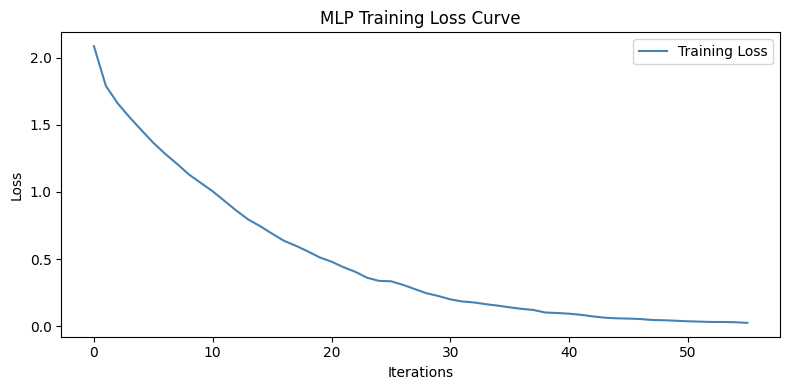


Model saved! Run Step 3 next.


In [6]:
# ============================================================
# STEP 2: Extract Features and Train Emotion Classifier
# Run this AFTER Step 1 completes successfully
# ============================================================

import numpy as np
import librosa
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ----------------------------
# 1. Feature Extraction (MFCC)
# ----------------------------
# MFCC = Mel Frequency Cepstral Coefficients
# These capture the "tone" and "texture" of speech
# Just like fingerprints — each emotion has its own MFCC pattern

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, duration=3, offset=0.5)

        # MFCCs — 40 coefficients capturing vocal tone
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc, axis=1)

        # Chroma — pitch class energy
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)

        # Mel spectrogram energy
        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        mel_mean = np.mean(mel, axis=1)

        # Combine all features
        features = np.concatenate([mfcc_mean, chroma_mean, mel_mean])
        return features

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print("Extracting features from all audio files...")
print("This takes 3-5 minutes. Please wait...\n")

X = []
y_labels = []

for i, row in df.iterrows():
    features = extract_features(row["path"])
    if features is not None:
        X.append(features)
        y_labels.append(row["emotion"])

X = np.array(X)
y_labels = np.array(y_labels)

print(f"Feature extraction complete!")
print(f"Total samples: {len(X)}")
print(f"Feature size per sample: {X.shape[1]}")

# ----------------------------
# 2. Encode Labels
# ----------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
print(f"\nEmotion classes: {list(le.classes_)}")

# ----------------------------
# 3. Train/Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale features (important for MLP)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# ----------------------------
# 4. Train MLP Classifier
# ----------------------------
print("\nTraining MLP Neural Network...")
print("(This takes about 1-2 minutes)\n")

model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)

model.fit(X_train, y_train)

# ----------------------------
# 5. Evaluate
# ----------------------------
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print("\n===== EVALUATION RESULTS =====")
print(f"Accuracy : {acc*100:.2f}%")
print(f"F1 Score : {f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ----------------------------
# 6. Plot training loss curve
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_, color='steelblue', label='Training Loss')
plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

# ----------------------------
# 7. Save model for Step 3
# ----------------------------
with open("emotion_model.pkl", "wb") as f:
    pickle.dump({
        "model": model,
        "scaler": scaler,
        "label_encoder": le,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred
    }, f)

print("\nModel saved! Run Step 3 next.")

Model Accuracy: 65.97%
Emotion classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


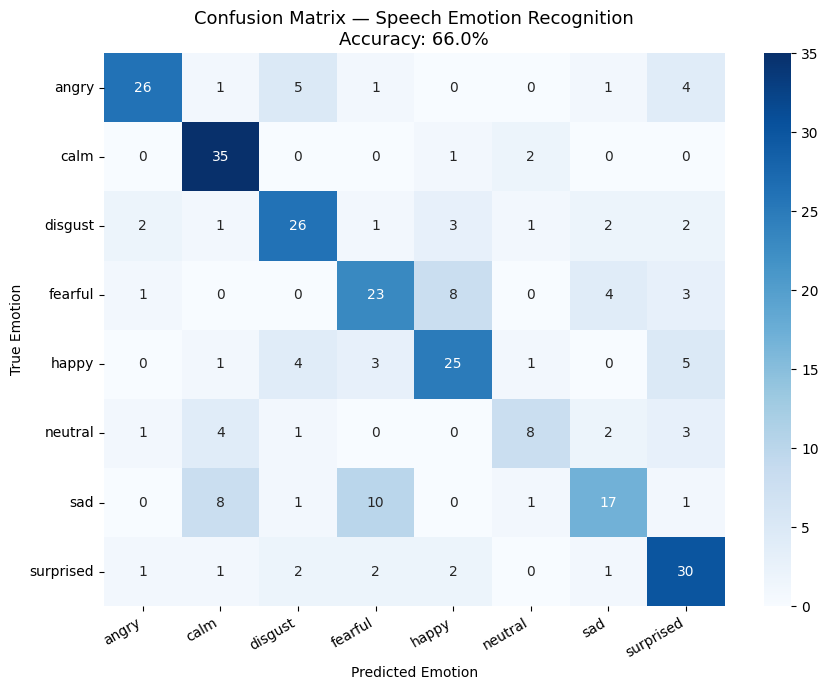

Saved: confusion_matrix_emotion.png


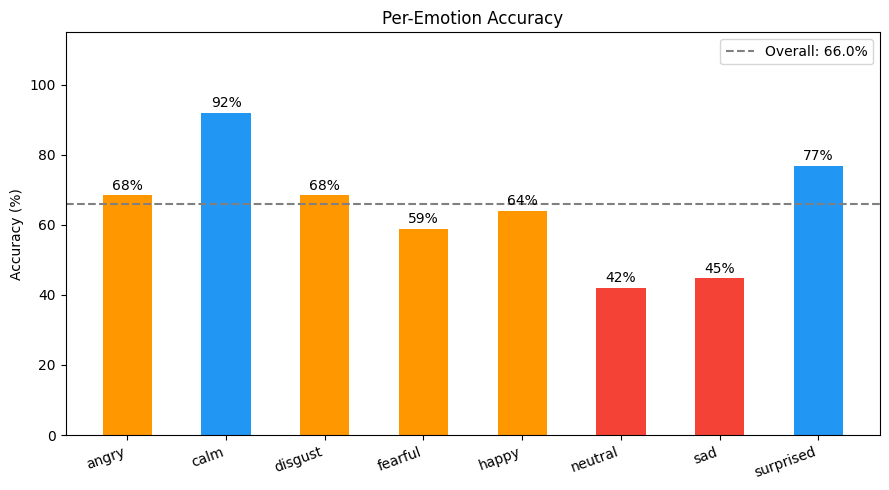

Saved: per_emotion_accuracy.png


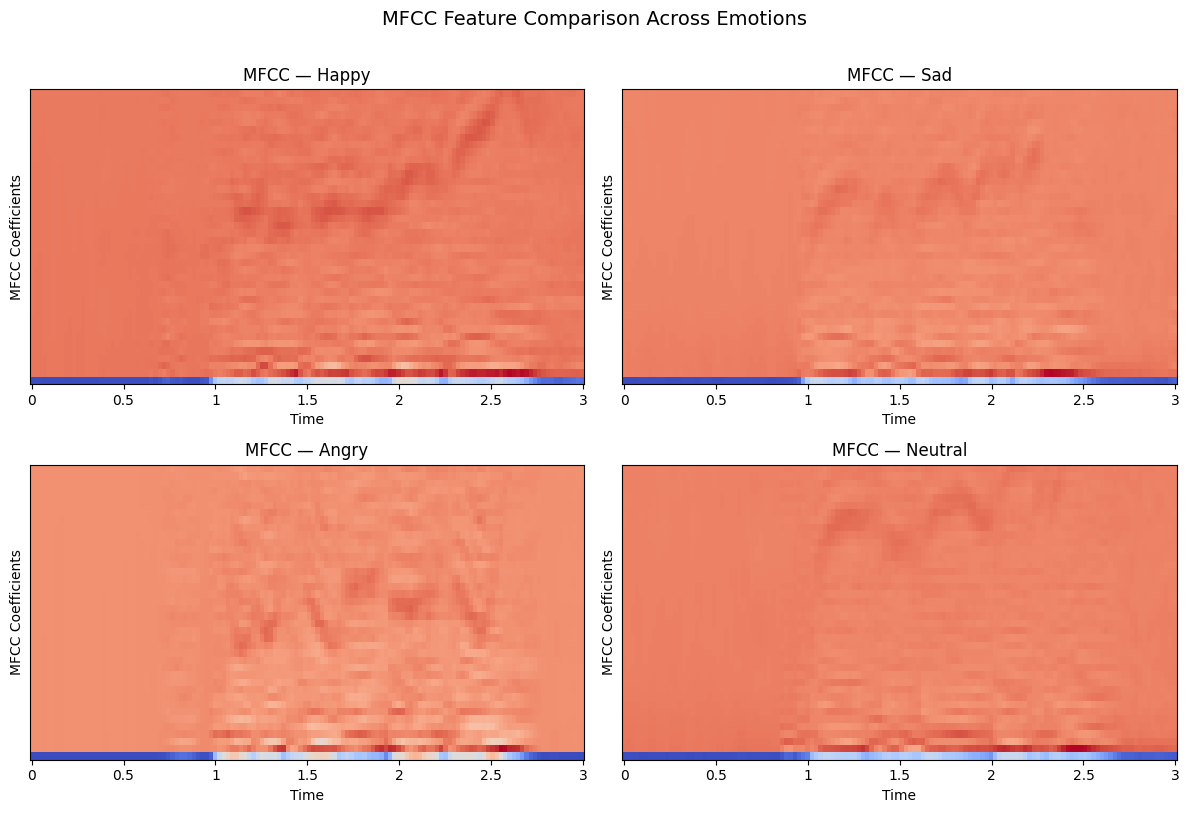

Saved: mfcc_comparison.png

===== SAMPLE PREDICTIONS =====
Actual       Predicted    Correct
------------------------------------
sad          sad          ✓
calm         calm         ✓
happy        happy        ✓
angry        disgust      ✗
neutral      calm         ✗
angry        surprised    ✗
angry        angry        ✓
fearful      happy        ✗
disgust      disgust      ✓
angry        angry        ✓
angry        angry        ✓
surprised    surprised    ✓
angry        surprised    ✗
sad          disgust      ✗
surprised    surprised    ✓

===== PROJECT COMPLETE =====
Files generated:
  - confusion_matrix_emotion.png
  - per_emotion_accuracy.png
  - mfcc_comparison.png
  - training_loss.png
  - sample_spectrogram.png


In [7]:
# ============================================================
# STEP 3: Visualize Results
# Run this AFTER Step 2 completes successfully
# ============================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
from sklearn.metrics import confusion_matrix, accuracy_score

# ----------------------------
# 1. Load saved model & results
# ----------------------------
with open("emotion_model.pkl", "rb") as f:
    saved = pickle.load(f)

model    = saved["model"]
scaler   = saved["scaler"]
le       = saved["label_encoder"]
X_test   = saved["X_test"]
y_test   = saved["y_test"]
y_pred   = saved["y_pred"]

class_names = le.classes_
acc = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {acc*100:.2f}%")
print(f"Emotion classes: {list(class_names)}")

# ----------------------------
# 2. Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f"Confusion Matrix — Speech Emotion Recognition\nAccuracy: {acc*100:.1f}%", fontsize=13)
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_emotion.png", dpi=150)
plt.show()
print("Saved: confusion_matrix_emotion.png")

# ----------------------------
# 3. Accuracy Bar Chart per Emotion
# ----------------------------
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(9, 5))
colors = ['#2196F3' if v >= 0.7 else '#FF9800' if v >= 0.5 else '#F44336'
          for v in per_class_acc]
bars = plt.bar(class_names, per_class_acc * 100, color=colors, width=0.5)
plt.axhline(y=acc*100, color='gray', linestyle='--', label=f'Overall: {acc*100:.1f}%')
plt.ylim(0, 115)
plt.ylabel("Accuracy (%)")
plt.title("Per-Emotion Accuracy")
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{val*100:.0f}%", ha='center', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig("per_emotion_accuracy.png", dpi=150)
plt.show()
print("Saved: per_emotion_accuracy.png")

# ----------------------------
# 4. MFCC Comparison across emotions
# ----------------------------
emotions_to_show = ['happy', 'sad', 'angry', 'neutral']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, emotion in enumerate(emotions_to_show):
    sample = df[df["emotion"] == emotion]["path"].iloc[0]
    y_audio, sr = librosa.load(sample, duration=3)
    mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=40)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[i])
    axes[i].set_title(f"MFCC — {emotion.capitalize()}", fontsize=12)
    axes[i].set_ylabel("MFCC Coefficients")

plt.suptitle("MFCC Feature Comparison Across Emotions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("mfcc_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mfcc_comparison.png")

# ----------------------------
# 5. Sample Predictions
# ----------------------------
print("\n===== SAMPLE PREDICTIONS =====")
print(f"{'Actual':<12} {'Predicted':<12} {'Correct'}")
print("-" * 36)
for i in range(15):
    actual    = le.inverse_transform([y_test[i]])[0]
    predicted = le.inverse_transform([y_pred[i]])[0]
    correct   = "✓" if actual == predicted else "✗"
    print(f"{actual:<12} {predicted:<12} {correct}")

print("\n===== PROJECT COMPLETE =====")
print("Files generated:")
print("  - confusion_matrix_emotion.png")
print("  - per_emotion_accuracy.png")
print("  - mfcc_comparison.png")
print("  - training_loss.png")
print("  - sample_spectrogram.png")